In [ ]:
import pandas as pd

df = pd.read_csv('complex_method.csv', sep=";")
df.head()

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,ComplexMethod
0,django/shortcuts.py,django-5.2,5.2,194.0,74.0,101.0,9.0,49.0,33.0,31.0,...,167.179,2.095,350.279,19.46,0.055726,0.0,0.0,0.0,0.0,0
1,django/__init__.py,django-5.2,5.2,24.0,13.0,14.0,0.0,5.0,5.0,3.0,...,4.755,0.500,2.377,0.132,0.001585,0.0,0.0,0.0,0.0,0
2,django/__main__.py,django-5.2,5.2,10.0,4.0,3.0,0.0,4.0,3.0,0.0,...,4.755,0.500,2.377,0.132,0.001585,0.0,0.0,0.0,0.0,0
3,django/apps/config.py,django-5.2,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
4,django/apps/registry.py,django-5.2,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,0


In [ ]:
df['project'].unique()

array(['django-5.2', 'matplotlib-3.10.0', 'numpy-2.1.0', 'scipy-1.14.0',
       'django-2.2', 'django-3.2', 'django-4.2', 'matplotlib-3.3.0',
       'matplotlib-3.4.0', 'matplotlib-3.6.0', 'matplotlib-3.8.0',
       'numpy-1.21.0', 'numpy-1.23.0', 'numpy-1.25.0', 'numpy-2.0.0',
       'scipy-1.11.0', 'scipy-1.13.0', 'scipy-1.7.0', 'scipy-1.9.0'],
      dtype=object)

In [ ]:
df['project'] = df['project'].str.replace(r'-.*$', '', regex=True)

In [ ]:
df.head()

,file,project,version,loc,lloc,sloc,comments,multi,blank,cyclo,...,V,D,E,T,B,cbo,lcom,DIT,rfc,ComplexMethod
0,django/shortcuts.py,django,5.2,194.0,74.0,101.0,9.0,49.0,33.0,31.0,...,167.179,2.095,350.279,19.46,0.055726,0.0,0.0,0.0,0.0,0
1,django/__init__.py,django,5.2,24.0,13.0,14.0,0.0,5.0,5.0,3.0,...,4.755,0.500,2.377,0.132,0.001585,0.0,0.0,0.0,0.0,0
2,django/__main__.py,django,5.2,10.0,4.0,3.0,0.0,4.0,3.0,0.0,...,4.755,0.500,2.377,0.132,0.001585,0.0,0.0,0.0,0.0,0
3,django/apps/config.py,django,5.2,274.0,128.0,163.0,55.0,19.0,35.0,60.0,...,736.589,5.414,3987.94,221.552,0.24553,22.0,5.0,0.0,22.0,0
4,django/apps/registry.py,django,5.2,437.0,203.0,209.0,56.0,88.0,79.0,76.0,...,706.016,6.844,4.831.796,268.433,0.235339,35.0,1.0,0.0,54.0,0


In [ ]:
df['project'].unique()

array(['django', 'matplotlib', 'numpy', 'scipy'], dtype=object)

In [ ]:
df.isnull().sum()

,0
file,0
project,0
version,0
loc,0
lloc,0
sloc,0
comments,0
multi,0
blank,0
cyclo,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14591 entries, 0 to 14590
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   file           14591 non-null  object 
 1   project        14591 non-null  object 
 2   version        14591 non-null  object 
 3   loc            14591 non-null  float64
 4   lloc           14591 non-null  float64
 5   sloc           14591 non-null  float64
 6   comments       14591 non-null  float64
 7   multi          14591 non-null  float64
 8   blank          14591 non-null  float64
 9   cyclo          14591 non-null  float64
 10  wmc            14591 non-null  float64
 11  η1             14591 non-null  float64
 12  η2             14591 non-null  float64
 13  N1             14591 non-null  float64
 14  N2             14591 non-null  float64
 15  η              14591 non-null  float64
 16  N              14591 non-null  float64
 17  N_hat          14591 non-null  object 
 18  V     

# **SPLIT DATA**

In [ ]:
from sklearn.model_selection import train_test_split

# Simpan metadata
meta = df[["file", "version", "project"]]

# Pisahkan fitur dan label
X = df.drop(columns=["file", "version", "project", "ComplexMethod"])
y = df["ComplexMethod"]

# Convert problematic columns to numeric, handling commas
problematic_cols = ['N_hat', 'V', 'E', 'T', 'B']
for col in problematic_cols:
    if col in X.columns:
        X[col] = X[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)


X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, meta, test_size=0.2, random_state=42, shuffle=True, stratify=y
)


forbidden = ["cyclo"]
X_train = X_train.drop(columns=forbidden)
X_test  = X_test.drop(columns=forbidden)

print("Fitur final:", X_train.columns.tolist())

Fitur final: ['loc', 'lloc', 'sloc', 'comments', 'multi', 'blank', 'wmc', 'η1', 'η2', 'N1', 'N2', 'η', 'N', 'N_hat', 'V', 'D', 'E', 'T', 'B', 'cbo', 'lcom', 'DIT', 'rfc']


# **FEATURE SCALING**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class ModifiedZScoreScaler(BaseEstimator, TransformerMixin):
    """
    Modified Z-score scaling (median & MAD).
    Cocok untuk data skewed / outlier-heavy.
    """
    def fit(self, X, y=None):
        self.medians_ = X.median()
        self.mads_ = (np.abs(X - self.medians_)).median()
        self.mads_ = self.mads_.replace(0, 1e-9)  # hindari division by zero
        return self

    def transform(self, X):
        return 0.6745 * (X - self.medians_) / self.mads_

In [ ]:
# Sebelum scaling
print("\n=== Sebelum Scaling ===")
print(X_train.head())

# Scaling
scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Setelah scaling
print("\n=== Setelah Scaling ===")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())


=== Sebelum Scaling ===
         loc   lloc   sloc  comments  multi  blank   wmc    η1     η2     N1  \
10746  446.0  327.0  345.0      18.0    8.0   76.0  74.0  13.0  146.0  176.0   
11606   15.0    9.0    6.0       0.0    0.0    6.0   2.0   0.0    0.0    0.0   
7090    43.0   13.0   13.0      16.0    7.0    7.0   0.0   1.0    2.0    1.0   
14206   24.0   15.0   18.0       1.0    0.0    5.0   2.0   4.0   10.0    7.0   
4718    16.0    4.0   12.0       0.0    0.0    4.0   1.0   0.0    0.0    0.0   

       ...     N_hat          V       D           E          T          B  \
10746  ...  109782.0  3312736.0  12.332  40853295.0  2269628.0  1104245.0   
11606  ...       0.0        0.0   0.000         0.0        0.0        0.0   
7090   ...      20.0     4755.0   0.500      2377.0      132.0     1585.0   
14206  ...   41219.0    79954.0   2.800    223872.0    12437.0    26651.0   
4718   ...       0.0        0.0   0.000         0.0        0.0        0.0   

        cbo  lcom  DIT   rfc  


# **FEATURE SELECTION**

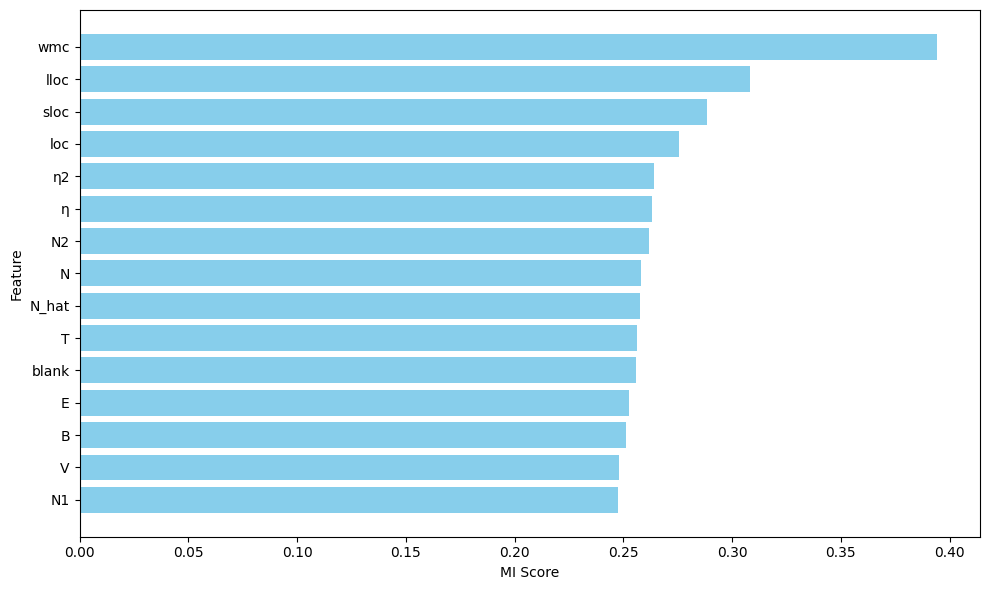

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import numpy as np

def select_topk_features_MI(X, y, k):
    """
    Feature selection menggunakan Mutual Information.
    Mengambil k fitur teratas berdasarkan skor MI.
    """
    scores = mutual_info_classif(X, y, random_state=42)
    mi_series = pd.Series(scores, index=X.columns)
    selected = mi_series.nlargest(k).index.tolist()
    return selected, scores

# Misal menggunakan top-k MI
selected_features, scores = select_topk_features_MI(X_train, y_train, k=15)

# Buat dataframe untuk plotting
mi_df = pd.DataFrame({
    "feature": X_train.columns,
    "mi_score": scores
}).sort_values("mi_score", ascending=True)

# Ambil data fitur yang terpilih
mi_selected_df = mi_df[mi_df["feature"].isin(selected_features)]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(mi_selected_df["feature"], mi_selected_df["mi_score"], color='skyblue')
# plt.title("Top-15 Features Based on Mutual Information")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
df['ComplexMethod'].unique()

array([0, 1])

In [ ]:
# top-k fitur dari train
X_train_topk = X_train[selected_features]
X_test_topk = X_test[selected_features]

# Scaling

scaler = ModifiedZScoreScaler()
X_train_scaled = scaler.fit_transform(X_train_topk)
X_test_scaled = scaler.transform(X_test_topk)

# DataFrame

X_train_final = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_final = pd.DataFrame(X_test_scaled, columns=selected_features)

# Gabung target dan metadata

train_final = pd.concat([meta_train.reset_index(drop=True),
                         X_train_final.reset_index(drop=True),
                         y_train.reset_index(drop=True)], axis=1)

test_final = pd.concat([meta_test.reset_index(drop=True),
                        X_test_final.reset_index(drop=True),
                        y_test.reset_index(drop=True)], axis=1)


train_final.to_csv("train_complexmethod.csv", index=False)
test_final.to_csv("test_complexmethod.csv", index=False)

print("✅ Dataset train & test dengan metadata berhasil disimpan!")

✅ Dataset train & test dengan metadata berhasil disimpan!


In [ ]:
dc = pd.read_csv('train_complexmethod.csv')
dc.head()

,file,version,project,wmc,lloc,sloc,loc,η2,η,N2,N,N_hat,T,blank,E,B,V,N1,ComplexMethod
0,numpy/core/tests/test_function_base.py,1.25.0,numpy,5.564625,5.511629,4.721500,3.124000,7.531917,6.028344,11.781267,12.610217,1.550231,168.781343,2.794357,191.056278,35.988717,38.280859,14.164500,0
1,scipy/special/_sf_error.py,1.11.0,scipy,-0.505875,-0.616686,-0.722679,-0.701125,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.578143,-0.674500,-0.674500,-0.674500,-0.674500,0
2,examples/lines_bars_and_markers/stem_plot.py,3.4.0,matplotlib,-0.674500,-0.539600,-0.610262,-0.452625,-0.562083,-0.548031,-0.584567,-0.586522,-0.674095,-0.664645,-0.529964,-0.663344,-0.621875,-0.618585,-0.590187,0
3,scipy/special/tests/test_precompute_expn_asy.py,1.9.0,scipy,-0.505875,-0.501057,-0.529964,-0.621250,-0.112417,-0.084312,-0.044967,-0.058652,0.160803,0.254076,-0.626321,0.376166,0.210368,0.265701,-0.084312,0
4,django/contrib/auth/migrations/0009_alter_user...,3.2,django,-0.590187,-0.713043,-0.626321,-0.692250,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,-0.674500,0


ComplexMethod
0    10106
1     1566
Name: count, dtype: int64
ComplexMethod
0    0.865833
1    0.134167
Name: proportion, dtype: float64


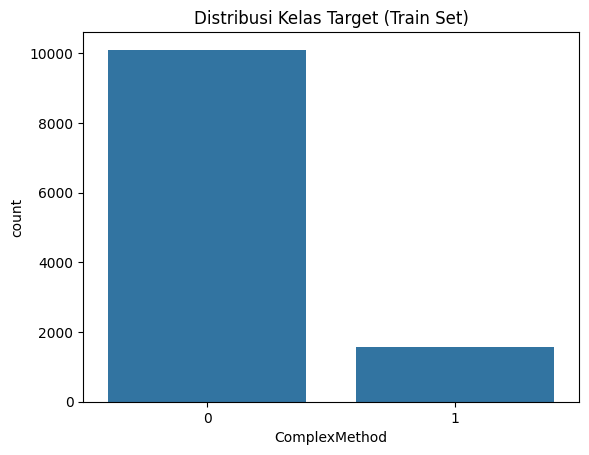

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Jumlah tiap kelas
print(y_train.value_counts())

# Proporsi tiap kelas
print(y_train.value_counts(normalize=True))

# Visualisasi distribusi target
sns.countplot(x=y_train)
plt.title("Distribusi Kelas Target (Train Set)")
plt.show()

# **MODELING**

# **Random Forest**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
import numpy as np

n_estimators_list = [100, 200, 300]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
# Untuk menyimpan hasil akhir per n_estimators
mean_acc_results = []
mean_mcc_results = []

for n in n_estimators_list:

    print("\n\n======================")
    print(f"   n_estimators = {n}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    # === CV berjalan untuk setiap n_estimators ===
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # === Feature Selection ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # === Model ===
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi n_estimators ===
    mean_acc_results.append(np.mean(acc_all))
    mean_mcc_results.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for n_estimators =", n)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")



   n_estimators = 100

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N', 'η', 'N2', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.95460
MCC: 0.83806
Training Time:  0.45864 sec
Prediksi Time:  0.04610 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'N', 'η2', 'η', 'N2', 'blank', 'N_hat', 'N1', 'T', 'E', 'B', 'V']
Accuracy: 0.96445
MCC: 0.86814
Training Time:  0.45593 sec
Prediksi Time:  0.04649 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'η', 'blank', 'N2', 'N_hat', 'N', 'T', 'E', 'N1', 'V', 'B']
Accuracy: 0.96058
MCC: 0.85589
Training Time:  0.44050 sec
Prediksi Time:  0.04699 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', 'N', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.96101
MCC: 0.85647
Training Time:  0.48662 sec
Prediksi Time:  0.04567 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', 'N

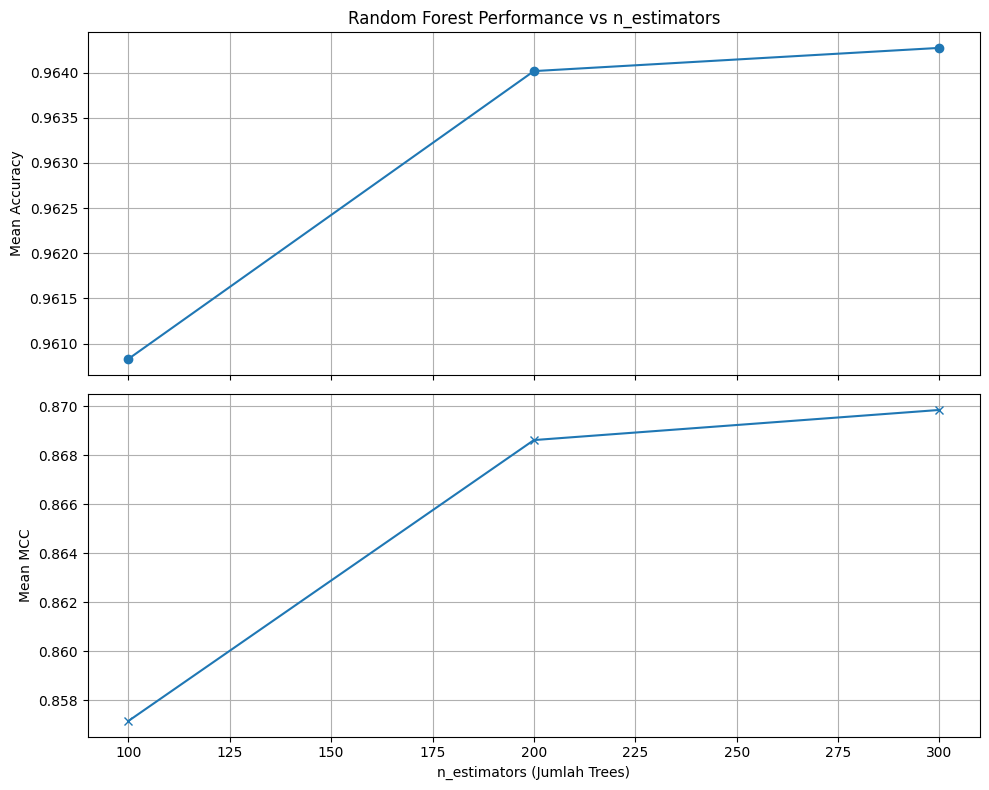

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Accuracy
axes[0].plot(n_estimators_list, mean_acc_results, marker='o')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_title('Random Forest Performance vs n_estimators')
axes[0].grid(True)

#  MCC
axes[1].plot(n_estimators_list, mean_mcc_results, marker='x')
axes[1].set_xlabel('n_estimators (Jumlah Trees)')
axes[1].set_ylabel('Mean MCC')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# **KNN**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np

n_neighbors_list = [1, 3, 5, 7, 9, 11]

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

# Final results
mean_acc_knn = []
mean_mcc_knn = []
mean_train_knn = []
mean_pred_knn = []

for k in n_neighbors_list:

    print("\n\n======================")
    print(f"        K = {k}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        model = KNeighborsClassifier(
            n_neighbors=k,
            weights='distance',
            p=2
        )

        # Training time
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # Prediction time
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} =====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time: {pred_time:.5f} sec")
        fold_counter += 1

    # Store mean results
    mean_acc_knn.append(np.mean(acc_all))
    mean_mcc_knn.append(np.mean(mcc_all))
    mean_train_knn.append(np.mean(train_time_all))
    mean_pred_knn.append(np.mean(predict_time_all))

    print("\n>>> RESULT for K =", k)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")



        K = 1

===== Fold 1 =====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N', 'η', 'N2', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.97987
MCC: 0.91173
Training Time:  0.01901 sec
Prediction Time: 0.02932 sec

===== Fold 2 =====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'N', 'η2', 'η', 'N2', 'blank', 'N_hat', 'N1', 'T', 'E', 'B', 'V']
Accuracy: 0.97687
MCC: 0.90150
Training Time:  0.03333 sec
Prediction Time: 0.05121 sec

===== Fold 3 =====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'η', 'blank', 'N2', 'N_hat', 'N', 'T', 'E', 'N1', 'V', 'B']
Accuracy: 0.97901
MCC: 0.90862
Training Time:  0.03217 sec
Prediction Time: 0.05346 sec

===== Fold 4 =====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', 'N', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.98029
MCC: 0.91562
Training Time:  0.01891 sec
Prediction Time: 0.02906 sec

===== Fold 5 =====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', '

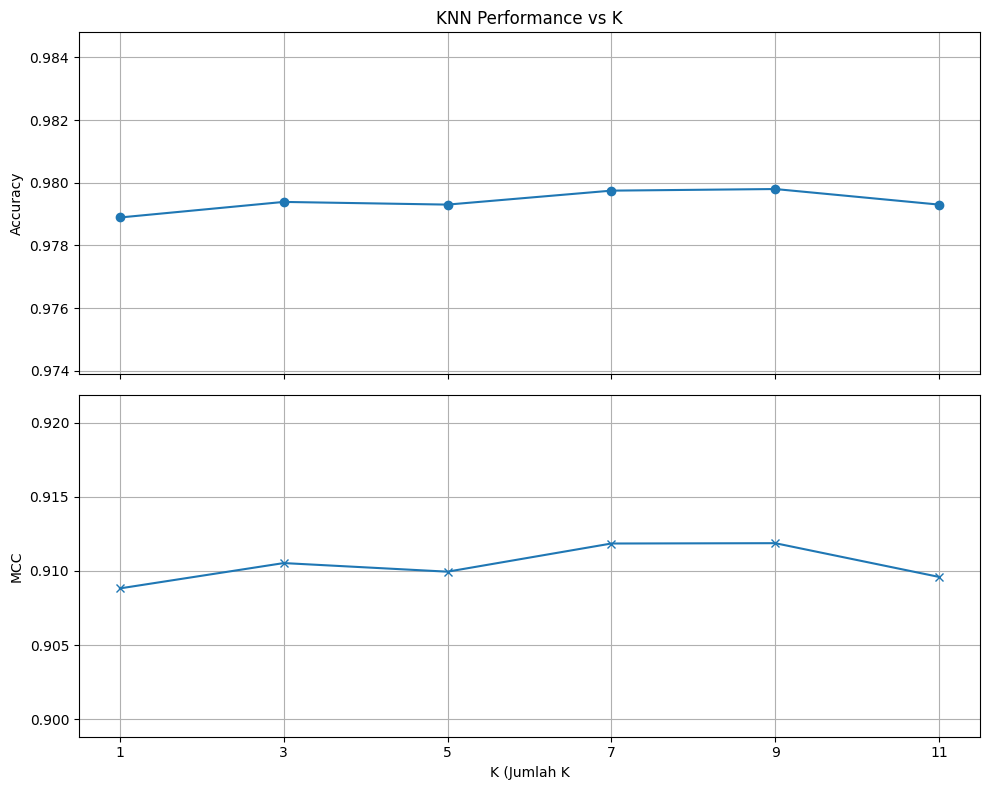

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ---- Accuracy ----
axes[0].plot(n_neighbors_list, mean_acc_knn, marker='o')
axes[0].set_ylabel("Accuracy")
axes[0].set_title("KNN Performance vs K")
axes[0].grid(True)
axes[0].set_ylim(min(mean_acc_knn)-0.005, max(mean_acc_knn)+0.005)

# ---- MCC ----
axes[1].plot(n_neighbors_list, mean_mcc_knn, marker='x')
axes[1].set_xlabel("K (Jumlah K")
axes[1].set_ylabel("MCC")
axes[1].grid(True)
axes[1].set_ylim(min(mean_mcc_knn)-0.01, max(mean_mcc_knn)+0.01)

# Set X-ticks agar sesuai angka K
plt.xticks(n_neighbors_list)

plt.tight_layout()
plt.show()

# **Logistic Regresion**

In [ ]:
import time
import numpy as np
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, matthews_corrcoef

C_list = [0.001, 0.01, 0.1, 1, 10, 100]

mean_acc_lr = []
mean_mcc_lr = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("  LOGISTIC REGRESSION EVALUATION")
print("===============================\n")

for C in C_list:

    print("\n\n=====================")
    print(f"        C = {C}")
    print("=====================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature Selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # Model
        model = LogisticRegression(C=C, max_iter=3000, solver='lbfgs')

        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediction Time:{pred_time:.5f} sec")

        fold_counter += 1

    # Simpan hasil rata-rata
    mean_acc_lr.append(np.mean(acc_all))
    mean_mcc_lr.append(np.mean(mcc_all))

    print("\n>>> RESULT for C =", C)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {np.mean(train_time_all):.5f} sec")
    print(f"Mean Predict Time:  {np.mean(predict_time_all):.5f} sec")


  LOGISTIC REGRESSION EVALUATION



        C = 0.001

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N', 'η', 'N2', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.98887
MCC: 0.95139
Training Time:  0.24402 sec
Prediction Time:0.00211 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'N', 'η2', 'η', 'N2', 'blank', 'N_hat', 'N1', 'T', 'E', 'B', 'V']
Accuracy: 0.98330
MCC: 0.92684
Training Time:  0.19812 sec
Prediction Time:0.00180 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'η', 'blank', 'N2', 'N_hat', 'N', 'T', 'E', 'N1', 'V', 'B']
Accuracy: 0.98243
MCC: 0.92270
Training Time:  0.20019 sec
Prediction Time:0.00231 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', 'N', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.98286
MCC: 0.92466
Training Time:  0.23531 sec
Prediction Time:0.00177 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sl

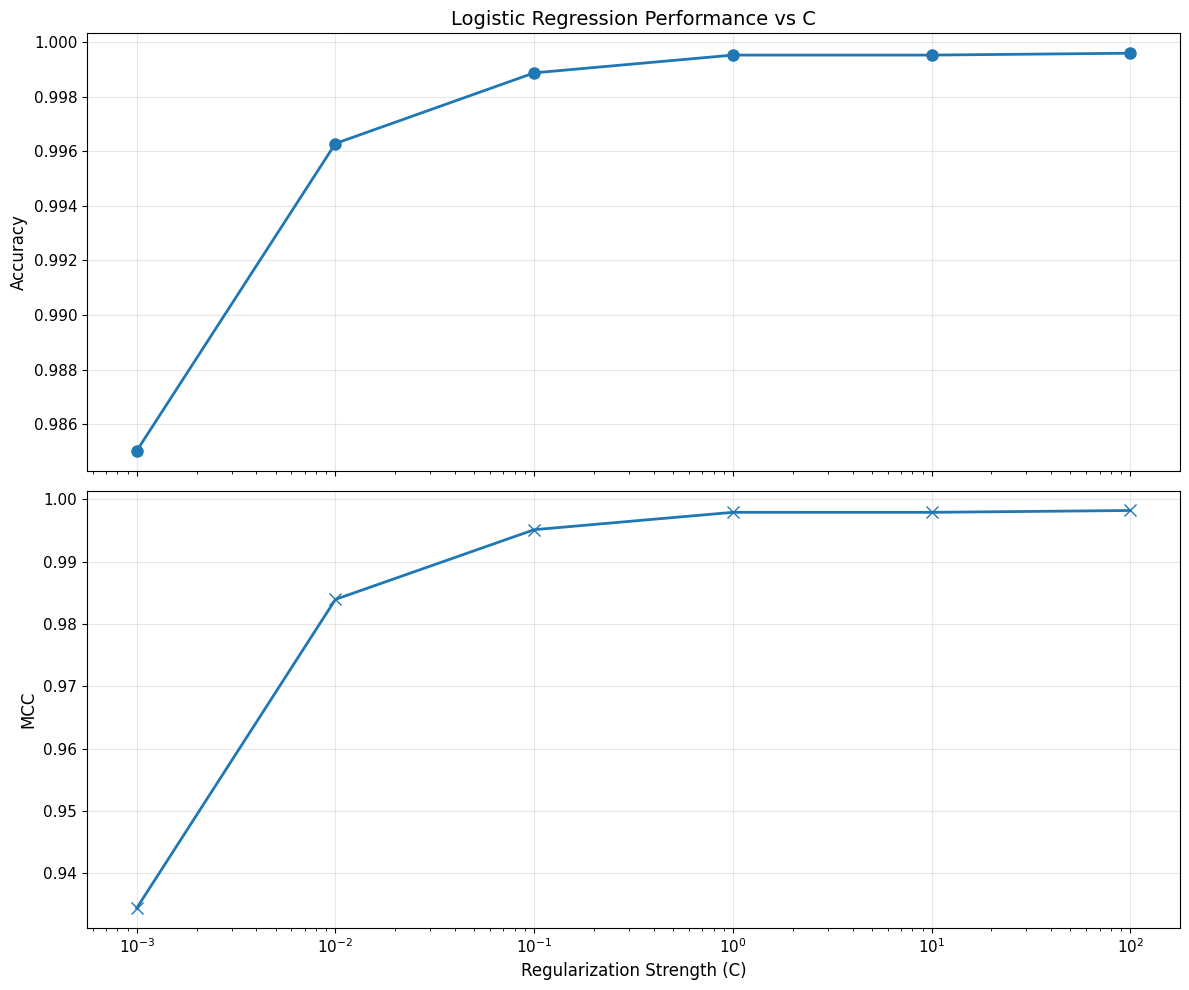

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Accuracy
axes[0].plot(C_list, mean_acc_lr, marker='o', linewidth=2, markersize=8)
axes[0].set_xscale('log')
axes[0].set_ylabel("Accuracy", fontsize=12)
axes[0].set_title("Logistic Regression Performance vs C", fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='both', labelsize=11)

# MCC
axes[1].plot(C_list, mean_mcc_lr, marker='x', linewidth=2, markersize=8)
axes[1].set_xscale('log')
axes[1].set_xlabel("Regularization Strength (C)", fontsize=12)
axes[1].set_ylabel("MCC", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='both', labelsize=11)

# Set X-ticks agar sesuai angka
plt.xticks(C_list)

plt.tight_layout()
plt.show()

# **MLP**

In [ ]:
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
import numpy as np

# Hyperparameter MLP
hidden_layer_sizes_list = [4, 8, 16, 32, 64, 100]

# Untuk menyimpan hasil mean
mean_acc_mlp = []
mean_mcc_mlp = []
train_time_all = []
predict_time_all = []
fold_counter = 1

# Repeated CV
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("      MLP CLASSIFIER EVALUATION")
print("===============================\n")

for h in hidden_layer_sizes_list:

    print("\n\n======================")
    print(f"  Hidden Layer = {h}")
    print("======================")

    acc_all = []
    mcc_all = []
    train_time_all = []
    predict_time_all = []

    fold_counter = 1

    # ==== Cross Validation ====
    for train_idx, test_idx in rskf.split(X_train, y_train):

        # Ambil fold
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx]
        y_test_fold  = y_train.iloc[test_idx]

        # Feature selection
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)
        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # Scaling per fold
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # ==== MLP Model ====
        model = MLPClassifier(
            hidden_layer_sizes=(h,),   # satu hidden layer
            activation='relu',
            solver='adam',
            max_iter=2000,
            random_state=42
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(X_train_scaled, y_train_fold)
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled)
        pred_time = time.time() - start_pred

        model.fit(X_train_scaled, y_train_fold)
        y_pred = model.predict(X_test_scaled)

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all.append(train_time)
        predict_time_all.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi Hidden Layer ===
    mean_acc_mlp.append(np.mean(acc_all))
    mean_mcc_mlp.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all)
    mean_pred = np.mean(predict_time_all)

    print("\n>>> RESULT for Hidden Layer =", hidden_layer_sizes_list)
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


      MLP CLASSIFIER EVALUATION



  Hidden Layer = 4

===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N', 'η', 'N2', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.99572
MCC: 0.98176
Training Time:  5.26886 sec
Prediksi Time:  0.00222 sec

===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'N', 'η2', 'η', 'N2', 'blank', 'N_hat', 'N1', 'T', 'E', 'B', 'V']
Accuracy: 0.99400
MCC: 0.97475
Training Time:  5.77664 sec
Prediksi Time:  0.00228 sec

===== Fold 3 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'η', 'blank', 'N2', 'N_hat', 'N', 'T', 'E', 'N1', 'V', 'B']
Accuracy: 0.99829
MCC: 0.99262
Training Time:  5.07151 sec
Prediksi Time:  0.00217 sec

===== Fold 4 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η', 'η2', 'N2', 'N', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.99743
MCC: 0.98902
Training Time:  3.66609 sec
Prediksi Time:  0.00167 sec

===== Fold 5 ====
Selected features: ['wmc', 'lloc', 'sl

Itepretasi:

Konfigurasi hidden layer = 8 memberikan keseimbangan terbaik antara performa klasifikasi dan efisiensi komputasi, dengan MCC tertinggi dibandingkan konfigurasi lainnya, sementara peningkatan jumlah neuron tidak menghasilkan peningkatan performa yang signifikan.

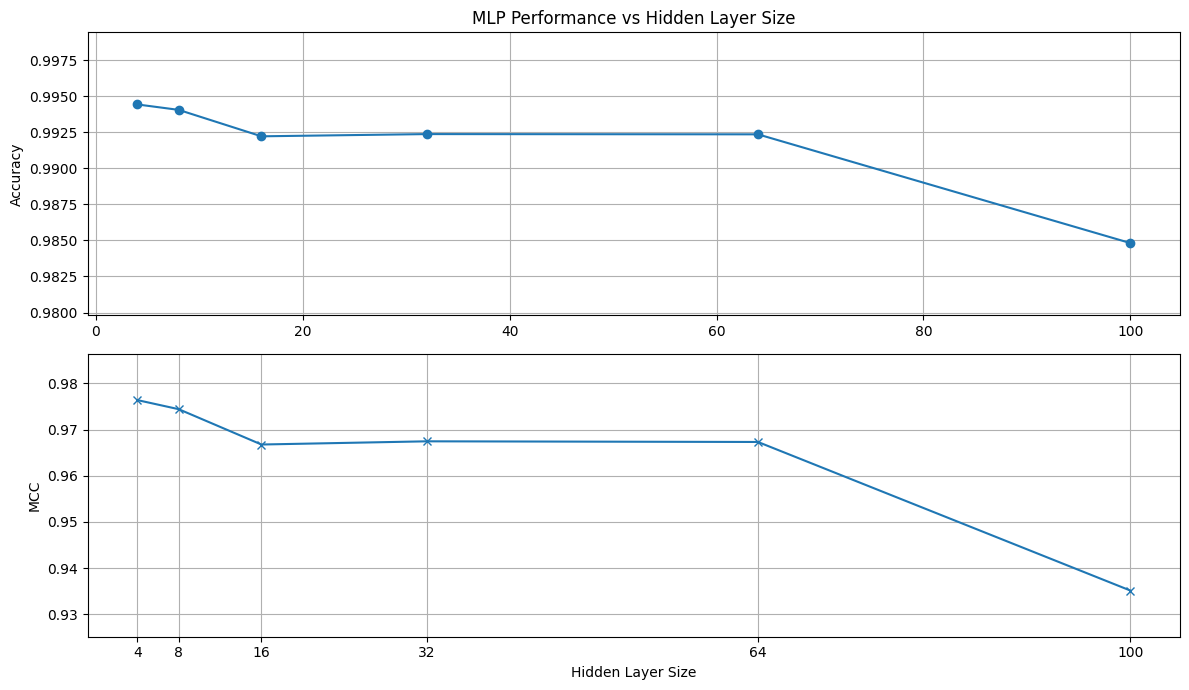

In [ ]:
plt.figure(figsize=(12, 7))

# ==== Plot Accuracy ====
plt.subplot(2, 1, 1)
plt.plot(hidden_layer_sizes_list, mean_acc_mlp, marker='o')
plt.title("MLP Performance vs Hidden Layer Size")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_mlp) - 0.005, max(mean_acc_mlp) + 0.005)

# ==== Plot MCC ====
plt.subplot(2, 1, 2)
plt.plot(hidden_layer_sizes_list, mean_mcc_mlp, marker='x')
plt.xlabel("Hidden Layer Size")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_mlp) - 0.01, max(mean_mcc_mlp) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(hidden_layer_sizes_list)

plt.tight_layout()
plt.show()

# **TABNET**

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00


In [ ]:
import time
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, matthews_corrcoef
import numpy as np
import torch
import pandas as pd # Ensure pandas is imported

# Hyperparameter list
n_d_a_list = [8, 16, 32, 64]

mean_acc_tabnet = []
mean_mcc_tabnet = []

rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

print("\n===============================")
print("         TABNET EVALUATION")
print("===============================\n")

for dim in n_d_a_list:

    print(f"\n\n======================\n  n_d = n_a = {dim}\n======================")

    acc_all = []
    mcc_all = []
    train_time_all_fold = [] # Renamed to avoid conflict with outer scope
    predict_time_all_fold = [] # Renamed to avoid conflict with outer scope
    fold_counter = 1

    for train_idx, test_idx in rskf.split(X_train, y_train):

        # === Ambil fold ===
        X_train_fold = X_train.iloc[train_idx].copy()
        X_test_fold  = X_train.iloc[test_idx].copy()
        y_train_fold = y_train.iloc[train_idx].values
        y_test_fold  = y_train.iloc[test_idx].values

        # === Feature Selection per fold ===
        selected_features, scores = select_topk_features_MI(X_train_fold, y_train_fold, k=15)

        X_train_fs = X_train_fold[selected_features]
        X_test_fs  = X_test_fold[selected_features]

        # === Scaling per fold ===
        scaler = ModifiedZScoreScaler()
        X_train_scaled = scaler.fit_transform(X_train_fs)
        X_test_scaled  = scaler.transform(X_test_fs)

        # TabNet expects numpy arrays, so convert after scaling if they are DataFrames
        X_train_scaled_tabnet = X_train_scaled.values if isinstance(X_train_scaled, pd.DataFrame) else X_train_scaled
        X_test_scaled_tabnet = X_test_scaled.values if isinstance(X_test_scaled, pd.DataFrame) else X_test_scaled

        # === Model TabNet ===
        model = TabNetClassifier(
            n_d=dim,
            n_a=dim,
            n_steps=5,
            gamma=1.3,
            lambda_sparse=1e-4,
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=1e-3),
            verbose=0,
            seed=42 # Added seed for reproducibility
        )

        # === Timing Training ===
        start_train = time.time()
        model.fit(
            X_train_scaled_tabnet, y_train_fold,
            eval_set=[(X_test_scaled_tabnet, y_test_fold)],
            eval_metric=['accuracy'],
            max_epochs=100,
            patience=30
        )
        train_time = time.time() - start_train

        # === Timing Predict ===
        start_pred = time.time()
        y_pred = model.predict(X_test_scaled_tabnet)
        pred_time = time.time() - start_pred

        # === Evaluasi ===
        acc = accuracy_score(y_test_fold, y_pred)
        mcc = matthews_corrcoef(y_test_fold, y_pred)

        acc_all.append(acc)
        mcc_all.append(mcc)
        train_time_all_fold.append(train_time)
        predict_time_all_fold.append(pred_time)

        print(f"\n===== Fold {fold_counter} ====")
        print("Selected features:", list(selected_features))
        print(f"Accuracy: {acc:.5f}")
        print(f"MCC: {mcc:.5f}")
        print(f"Training Time:  {train_time:.5f} sec")
        print(f"Prediksi Time:  {pred_time:.5f} sec")
        fold_counter += 1

    # === Hasil per konfigurasi hidden dimension ===
    mean_acc_tabnet.append(np.mean(acc_all))
    mean_mcc_tabnet.append(np.mean(mcc_all))
    mean_train = np.mean(train_time_all_fold)
    mean_pred = np.mean(predict_time_all_fold)

    print(f"\n>>> RESULT for n_d = n_a = {dim}")
    print(f"Mean Accuracy: {np.mean(acc_all):.5f}")
    print(f"Mean MCC: {np.mean(mcc_all):.5f}")
    print(f"Mean Train Time:    {mean_train:.5f} sec")
    print(f"Mean Predict Time:  {mean_pred:.5f} sec")


         TABNET EVALUATION



  n_d = n_a = 8

Early stopping occurred at epoch 58 with best_epoch = 28 and best_val_0_accuracy = 0.94176


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 1 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N', 'η', 'N2', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'V']
Accuracy: 0.94176
MCC: 0.73552
Training Time:  61.84710 sec
Prediksi Time:  0.07093 sec

Early stopping occurred at epoch 51 with best_epoch = 21 and best_val_0_accuracy = 0.9439


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 2 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'N', 'η2', 'η', 'N2', 'blank', 'N_hat', 'N1', 'T', 'E', 'B', 'V']
Accuracy: 0.94390
MCC: 0.74829
Training Time:  36.14459 sec
Prediksi Time:  0.06725 sec

Early stopping occurred at epoch 48 with best_epoch = 18 and best_val_0_accuracy = 0.93745


...


===== Fold 23 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'blank', 'N2', 'η', 'N', 'N_hat', 'T', 'N1', 'E', 'V', 'B']
Accuracy: 0.99700
MCC: 0.98705
Training Time:  216.28780 sec
Prediksi Time:  0.17623 sec
Stop training because you reached max_epochs = 100 with best_epoch = 95 and best_val_0_accuracy = 0.99529


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 24 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'η', 'blank', 'N2', 'N', 'T', 'N_hat', 'N1', 'E', 'B', 'V']
Accuracy: 0.99529
MCC: 0.97961
Training Time:  212.33098 sec
Prediksi Time:  0.17136 sec

Early stopping occurred at epoch 99 with best_epoch = 69 and best_val_0_accuracy = 0.99957


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



===== Fold 25 ====
Selected features: ['wmc', 'lloc', 'sloc', 'loc', 'η2', 'N2', 'η', 'N', 'blank', 'N_hat', 'T', 'N1', 'E', 'B', 'D']
Accuracy: 0.99957
MCC: 0.99815
Training Time:  213.76357 sec
Prediksi Time:  0.18125 sec

>>> RESULT for n_d = n_a = 64
Mean Accuracy: 0.99510
Mean MCC: 0.97887
Mean Train Time:    189.76409 sec
Mean Predict Time:  0.19169 sec


Itepretasi:

Nilai n_d = n_a = 32 dipilih karena memberikan trade-off terbaik antara peningkatan MCC dan biaya komputasi, di mana peningkatan performa dibandingkan konfigurasi yang lebih kecil signifikan, sementara tambahan waktu pelatihan dibandingkan konfigurasi yang lebih besar relatif lebih efisien

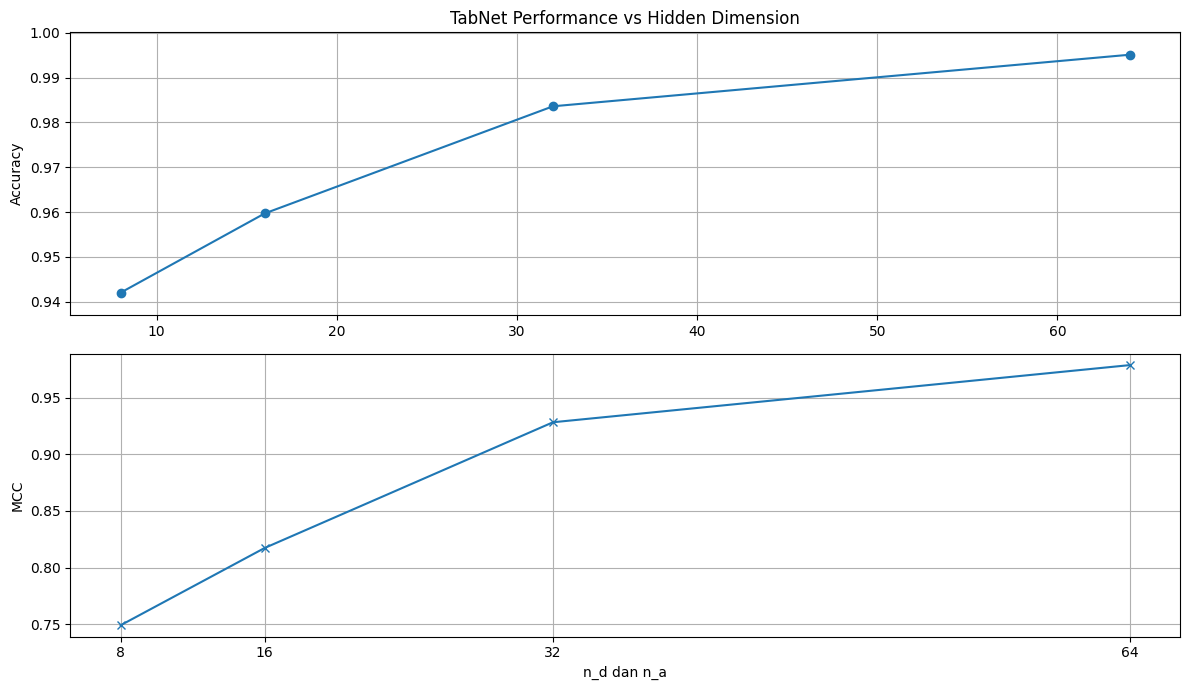

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Plot Accuracy
plt.subplot(2, 1, 1)
plt.plot(n_d_a_list, mean_acc_tabnet, marker='o')
plt.title("TabNet Performance vs Hidden Dimension")
plt.ylabel("Accuracy")
plt.grid(True)
plt.ylim(min(mean_acc_tabnet) - 0.005, max(mean_acc_tabnet) + 0.005)

# Plot MCC
plt.subplot(2, 1, 2)
plt.plot(n_d_a_list, mean_mcc_tabnet, marker='x')
plt.xlabel("n_d dan n_a")
plt.ylabel("MCC")
plt.grid(True)
plt.ylim(min(mean_mcc_tabnet) - 0.01, max(mean_mcc_tabnet) + 0.01)

# Set X-ticks agar sesuai angka
plt.xticks(n_d_a_list)

plt.tight_layout()
plt.show()